In [3]:
!pip install -q tensorflow tensorflow-datasets matplotlib opencv-python
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt, os, pandas as pd, cv2
from tensorflow.keras import layers, models, applications, callbacks
print('TF:', tf.__version__)

TF: 2.19.0


In [4]:
import pathlib
DATA_DIR = '/mnt/data/landmarks_dataset'
os.makedirs(DATA_DIR, exist_ok=True)
csv_path = os.path.join(DATA_DIR, 'annotations.csv')
if not os.path.exists(csv_path):
    from PIL import Image, ImageDraw
    labels = ['taj_mahal', 'qutub_minar']
    rows = []
    for i,label in enumerate(labels):
        img = Image.new('RGB', (300,300), (255,255,255))
        draw = ImageDraw.Draw(img)
        draw.rectangle([60,60,240,240], outline='black')
        p = os.path.join(DATA_DIR, f'{label}_{i}.jpg')
        img.save(p)
        rows.append({'image_path': p, 'label': i, 'xmin': 60, 'ymin': 60, 'xmax': 240, 'ymax': 240})
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    print('Created demo dataset at', DATA_DIR)
else:
    print('Found annotations.csv at', csv_path)
annotations = pd.read_csv(csv_path)
annotations.head()

Created demo dataset at /mnt/data/landmarks_dataset


,image_path,label,xmin,ymin,xmax,ymax
0,/mnt/data/landmarks_dataset/taj_mahal_0.jpg,0,60,60,240,240
1,/mnt/data/landmarks_dataset/qutub_minar_1.jpg,1,60,60,240,240


In [8]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 8

def load_and_preprocess(row):
    # Read and decode the image
    img = tf.io.read_file(row['image_path'])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    # Label
    cls = tf.cast(row['label'], tf.int32)

    # Bounding box
    bbox = tf.stack([row['xmin'], row['ymin'], row['xmax'], row['ymax']])
    bbox = tf.cast(bbox, tf.float32)
    bbox = bbox / 300.0

    return img, (cls, bbox)

# Assuming `annotations` is a dict with keys:
# ['image_path', 'label', 'xmin', 'ymin', 'xmax', 'ymax']
ds = tf.data.Dataset.from_tensor_slices(dict(annotations))
ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Test one batch
for batch in ds.take(1):
    images, targets = batch
    labels_batch, bboxes_batch = targets
    print('images', images.shape, 'labels', labels_batch.shape, 'bboxes', bboxes_batch.shape)


images (2, 224, 224, 3) labels (2,) bboxes (2, 4)


In [9]:
num_classes = annotations['label'].nunique()
backbone = applications.MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights='imagenet')
backbone.trainable = False

inputs = layers.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x = backbone(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

cls = layers.Dense(128, activation='relu')(x)
cls = layers.Dense(num_classes, activation='softmax', name='class_output')(cls)

bbox = layers.Dense(128, activation='relu')(x)
bbox = layers.Dense(4, activation='sigmoid', name='bbox_output')(bbox)

model = models.Model(inputs=inputs, outputs=[cls, bbox])
model.compile(optimizer='adam', loss={'class_output':'sparse_categorical_crossentropy','bbox_output':'mse'}, metrics={'class_output':'accuracy'})
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 2)         │        258 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        516 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,586,694 (9.87 MB)

 Trainable params: 328,710 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
import tensorflow as tf
from tensorflow.keras import callbacks


# Dataset setup

IMG_SIZE = 224
BATCH_SIZE = 8

def load_and_preprocess(row):
    # Reading and decoding the image
    img = tf.io.read_file(row['image_path'])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    # Labeling
    cls = tf.cast(row['label'], tf.int32)

    # Bounding box (we'll normalize if original image was 300x300)
    bbox = tf.stack([row['xmin'], row['ymin'], row['xmax'], row['ymax']])
    bbox = tf.cast(bbox, tf.float32)
    bbox = bbox / 300.0

    return img, (cls, bbox)

# Converting annotations dict to dataset
ds = tf.data.Dataset.from_tensor_slices(dict(annotations))
ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)


# Train/validation split

# Shuffling before splitting
ds = ds.shuffle(buffer_size=len(annotations), reshuffle_each_iteration=False)

val_size = int(0.2 * len(annotations))  # 20% validation
val_ds = ds.take(val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_ds = ds.skip(val_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


# Callbacks

es = callbacks.EarlyStopping(
    monitor='val_class_output_loss',  # per-output loss from model
    patience=3,
    restore_best_weights=True,
    mode='min'   # we want to minimize the loss
)


# Train

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[es]
)


# Save model

model.save('/mnt/data/notebooks/landmark_detection_model.h5')
print('Saved to /mnt/data/notebooks/landmark_detection_model.h5')


Epoch 1/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - bbox_output_loss: 0.0014 - class_output_accuracy: 0.5000 - class_output_loss: 0.8813 - loss: 0.8827   
Epoch 2/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - bbox_output_loss: 0.0069 - class_output_accuracy: 0.5000 - class_output_loss: 0.6978 - loss: 0.7047
Epoch 3/6


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_class_output_loss` which is not available. Available metrics are: bbox_output_loss,class_output_accuracy,class_output_loss,loss
  current = self.get_monitor_value(logs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - bbox_output_loss: 0.0104 - class_output_accuracy: 0.5000 - class_output_loss: 0.8715 - loss: 0.8819
Epoch 4/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - bbox_output_loss: 0.0121 - class_output_accuracy: 0.5000 - class_output_loss: 0.8929 - loss: 0.9050
Epoch 5/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - bbox_output_loss: 0.0126 - class_output_accuracy: 0.5000 - class_output_loss: 0.7592 - loss: 0.7718
Epoch 6/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - bbox_output_loss: 0.0126 - class_output_accuracy: 0.5000 - class_output_loss: 0.6945 - loss: 0.7071


Saved to /mnt/data/notebooks/landmark_detection_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Predicted label: 1
Predicted bbox (pixel coords approx): [ 58.05636048  23.23684394 295.62626481 242.10176468]


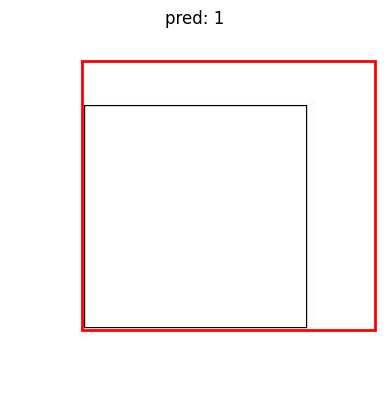

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Sample image
sample_img = annotations.loc[0, 'image_path']
img = tf.io.read_file(sample_img)
img = tf.image.decode_jpeg(img, channels=3)
img_resized = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

# Predict
pred_cls, pred_bbox = model.predict(tf.expand_dims(img_resized, 0))
pred_label = np.argmax(pred_cls[0])

# Scale bbox to original image size
h, w = img.shape[:2]
pred_bbox = pred_bbox[0] * np.array([w, h, w, h])  # [xmin, ymin, xmax, ymax] in pixels

# Print
print('Predicted label:', pred_label)
print('Predicted bbox (pixel coords approx):', pred_bbox)

# Plot
plt.imshow(img.numpy() / 255.0)  # convert uint8 to float
xmin, ymin, xmax, ymax = pred_bbox
rect = plt.Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    fill=False, color='r', linewidth=2
)
plt.gca().add_patch(rect)
plt.title(f'pred: {pred_label}')
plt.axis('off')
plt.show()

